In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns

from sklearn.model_selection import train_test_split

%config InlineBackend.figure_format = "retina"

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.0.2


In [2]:
RANDOM_SEED = 5781
np.random.seed(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [43]:
bikes = pd.read_csv(pm.get_data("bikes.csv"))

In [51]:
features = ["hour", "temperature", "humidity", "workingday"]

X = bikes[features]
Y = bikes["count"]

In [48]:
with pm.Model() as model_bikes:
    α = pm.Exponential("α", 1 / 10)
    μ = pmb.BART("μ", X, Y)
    y = pm.NegativeBinomial("y", mu=pm.math.abs(μ), alpha=α, observed=Y)
    idata_bikes = pm.sample(random_seed=RANDOM_SEED)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [α]
>PGBART: [μ]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 67 seconds.


/Users/rafael.calsaverini/miniforge3/envs/pymc/lib/python3.10/site-packages/arviz/plots/hdiplot.py:156: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/rafael.calsaverini/miniforge3/envs/pymc/lib/python3.10/site-packages/arviz/plots/hdiplot.py:156: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/rafael.calsaverini/miniforge3/envs/pymc/lib/python3.10/site-packages/arviz/plots/hdiplot.py:156: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_p

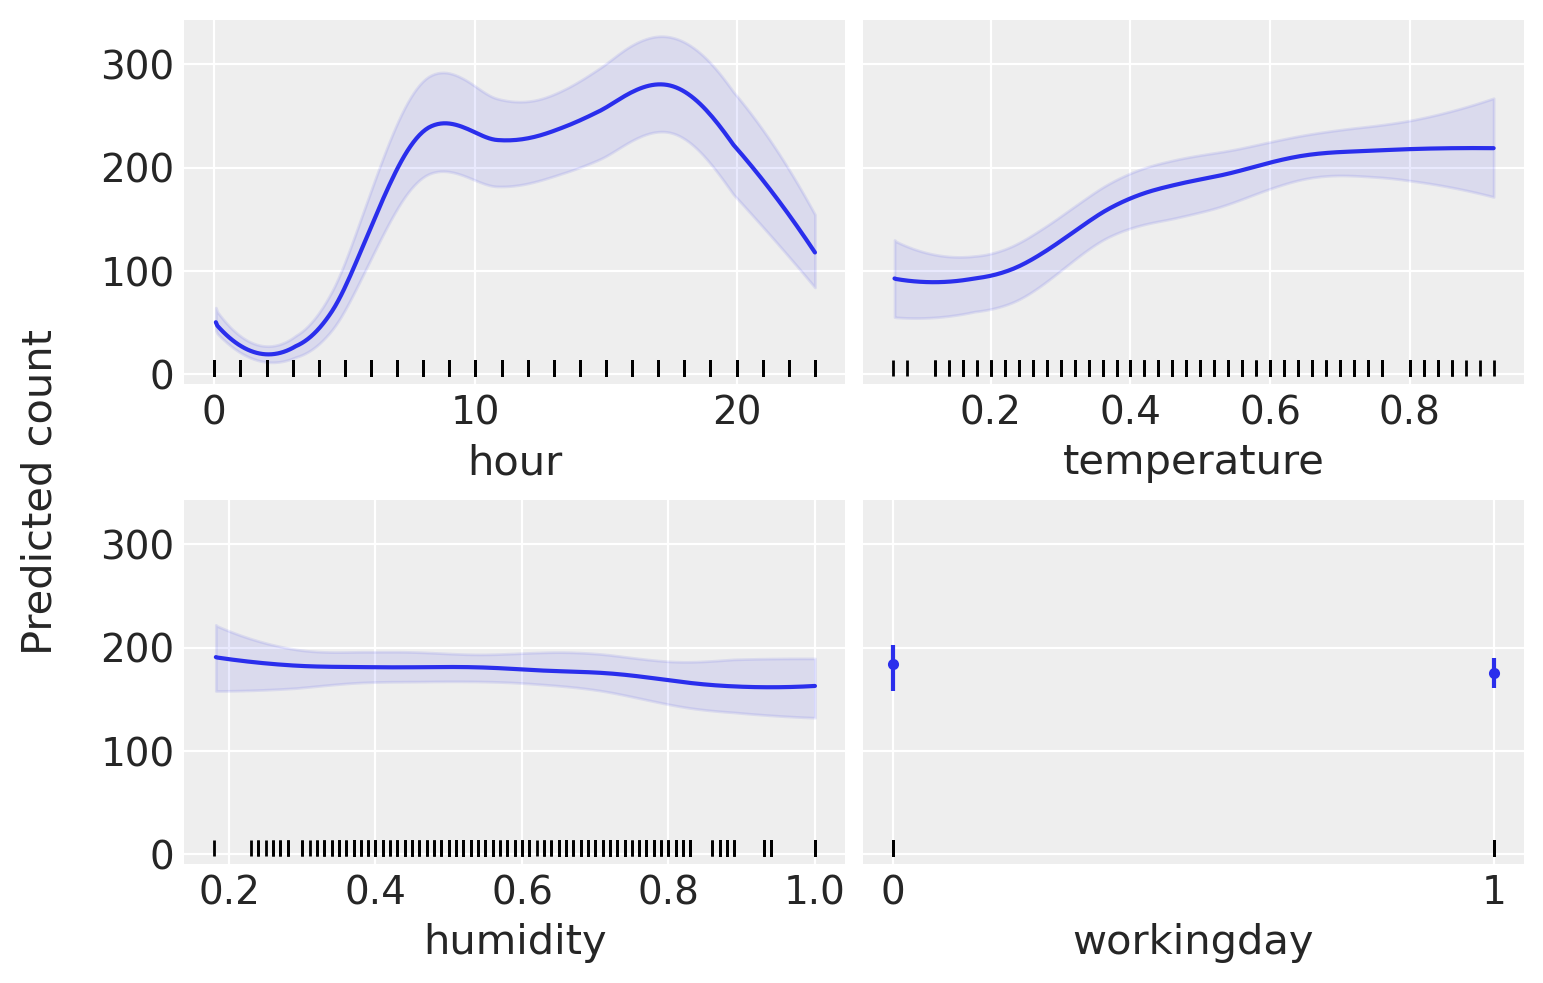

In [49]:
pmb.plot_dependence(μ, X=X, Y=Y, grid=(2, 2), var_discrete=[3])

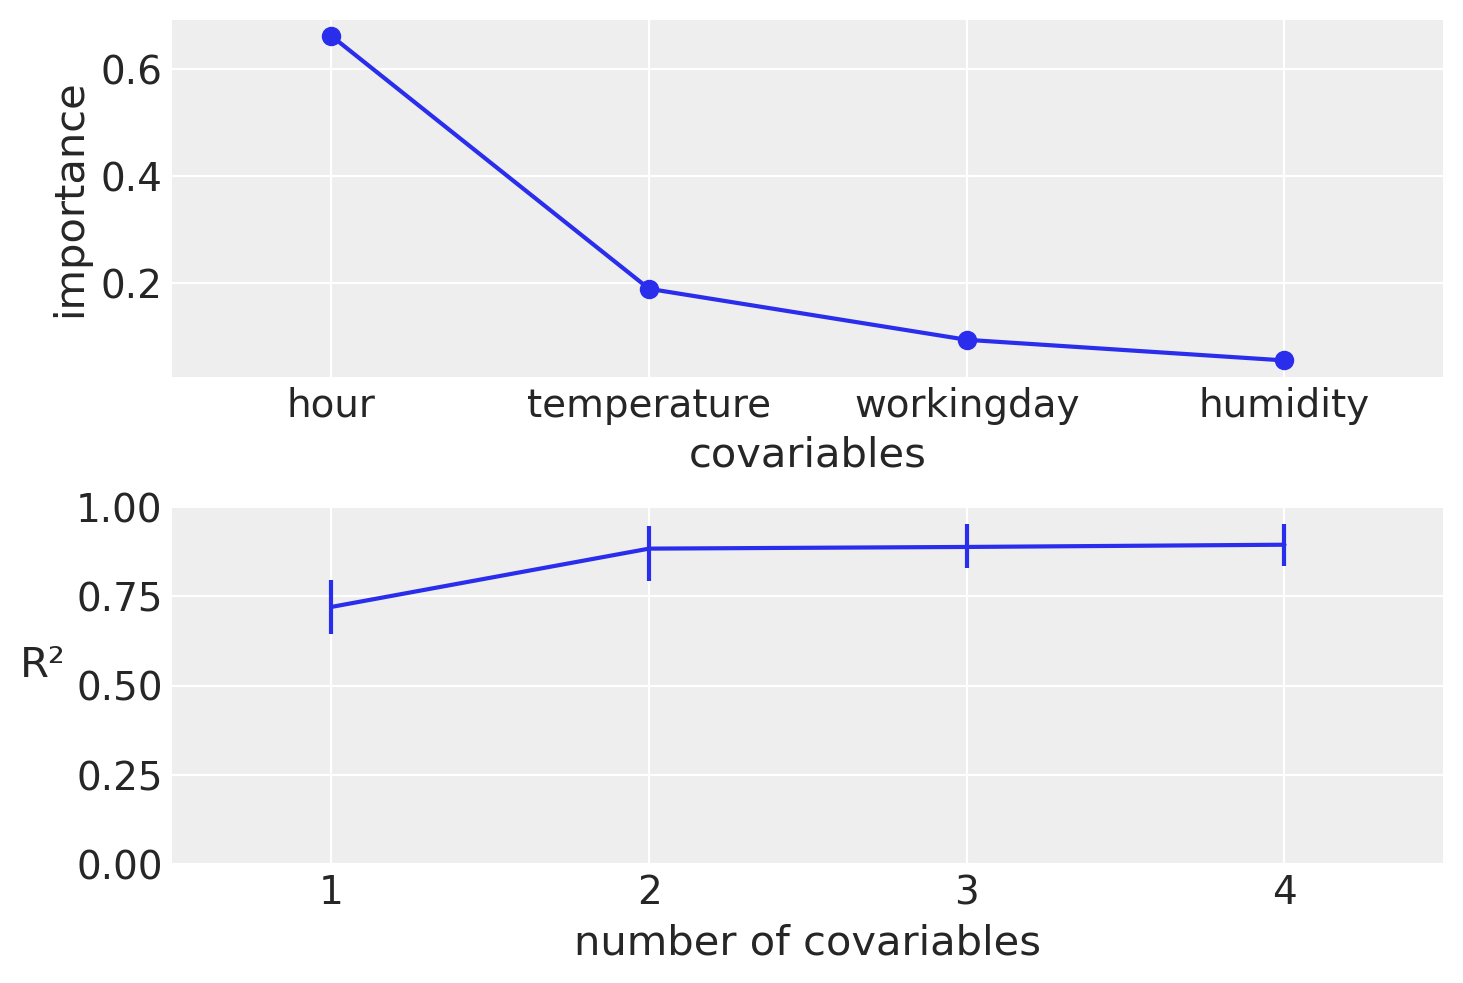

In [52]:
pmb.plot_variable_importance(idata_bikes, μ, X, samples=100);